In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 서울 범위 (대략적인 경계)
lat_min, lat_max = 37.413, 37.715
lon_min, lon_max = 126.734, 127.269

# 위도/경도당 500m 단위 계산
lat_step = 500 / 111000  # 약 0.0045도
lon_step = 500 / (np.cos(np.radians((lat_min + lat_max)/2)) * 111000)  # 약 0.0056도

n_rows = int((lat_max - lat_min) / lat_step)
n_cols = int((lon_max - lon_min) / lon_step)

# 격자 이미지 초기화
image = np.zeros((n_rows, n_cols, 3))  # RGB

In [ ]:
def latlon_to_pixel(lat, lon):
    row = int((lat_max - lat) / lat_step)
    col = int((lon - lon_min) / lon_step)
    return row, col

In [ ]:
import pandas as pd

# 도시숲 리스트
parks = [
    {"name": "월드컵공원", "area": 3471090, "lat": 37.568230, "lon": 126.897243},
    {"name": "남산공원", "area": 2896887, "lat": 37.555711, "lon": 126.992251},
    {"name": "안산도시자연공원", "area": 2088704, "lat": 37.582000, "lon": 126.951000},
    {"name": "올림픽공원", "area": 1450000, "lat": 37.520687, "lon": 127.117111},
    {"name": "서울숲", "area": 1156498, "lat": 37.544625, "lon": 127.039844},
    {"name": "북서울꿈의숲", "area": 662627, "lat": 37.620000, "lon": 127.041000},
    {"name": "보라매공원", "area": 425000, "lat": 37.493234, "lon": 126.917518},
    {"name": "매헌시민의숲", "area": 358992, "lat": 37.471695, "lon": 127.035205},
    {"name": "중랑캠핑숲", "area": 260000, "lat": 37.599600, "lon": 127.096400},
    {"name": "선유도공원", "area": 110400, "lat": 37.542436, "lon": 126.893525},
    {"name": "푸른식물원", "area": 103354, "lat": 37.564214, "lon": 127.001699},
    {"name": "현충원", "area": 1440000, "lat": 37.500598, "lon": 126.972640}
]


# 측정소 리스트
stations = [
    {"name": "강남구", "lat": 37.51796816, "lon": 127.0470598},
    {"name": "강동구", "lat": 37.54500381, "lon": 127.1368198},
    {"name": "강북구", "lat": 37.64793425, "lon": 127.0118697},
    {"name": "강서구", "lat": 37.54465666, "lon": 126.8351713},
    {"name": "관악구", "lat": 37.48064257, "lon": 126.9570309},
    {"name": "광진구", "lat": 37.54594731, "lon": 127.0929507},
    {"name": "구로구", "lat": 37.49884008, "lon": 126.8903092},
    {"name": "금천구", "lat": 37.4523532, "lon": 126.9083015},
    {"name": "노원구", "lat": 37.65748313, "lon": 127.0678641},
    {"name": "도봉구", "lat": 37.6542176, "lon": 127.0290801},
    {"name": "동대문구", "lat": 37.57640498, "lon": 127.028382},
    {"name": "동작구", "lat": 37.48097575, "lon": 126.9716337},
    {"name": "마포구", "lat": 37.55558837, "lon": 126.9055913},
    {"name": "서대문구", "lat": 37.59376657, "lon": 126.9496911},
    {"name": "서초구", "lat": 37.50458542, "lon": 126.9944717},
    {"name": "성동구", "lat": 37.54203238, "lon": 127.0496885},
    {"name": "성북구", "lat": 37.60681328, "lon": 127.0272803},
    {"name": "송파구", "lat": 37.50272901, "lon": 127.0925211},
    {"name": "양천구", "lat": 37.52597518, "lon": 126.8566021},
    {"name": "영등포구", "lat": 37.52596316, "lon": 126.8963671},
    {"name": "용산구", "lat": 37.53485709, "lon": 127.0002687},
    {"name": "은평구", "lat": 37.60987179, "lon": 126.9343249},
    {"name": "종로구", "lat": 37.57206117, "lon": 127.0050313},
    {"name": "중구", "lat": 37.56455419, "lon": 126.9756136},
    {"name": "중랑구", "lat": 37.58491272, "lon": 127.0940363}
]


# 격자 좌표 추가
for park in parks:
    park['x'], park['y'] = latlon_to_pixel(park['lat'], park['lon'])

for station in stations:
    station['x'], station['y'] = latlon_to_pixel(station['lat'], station['lon'])



In [ ]:
print(parks)
print(stations)

[{'name': '월드컵공원', 'area': 3471090, 'lat': 37.56823, 'lon': 126.897243, 'x': 32, 'y': 28}, {'name': '남산공원', 'area': 2896887, 'lat': 37.555711, 'lon': 126.992251, 'x': 35, 'y': 45}, {'name': '안산도시자연공원', 'area': 2088704, 'lat': 37.582, 'lon': 126.951, 'x': 29, 'y': 38}, {'name': '올림픽공원', 'area': 1450000, 'lat': 37.520687, 'lon': 127.117111, 'x': 43, 'y': 67}, {'name': '서울숲', 'area': 1156498, 'lat': 37.544625, 'lon': 127.039844, 'x': 37, 'y': 53}, {'name': '북서울꿈의숲', 'area': 662627, 'lat': 37.62, 'lon': 127.041, 'x': 21, 'y': 54}, {'name': '보라매공원', 'area': 425000, 'lat': 37.493234, 'lon': 126.917518, 'x': 49, 'y': 32}, {'name': '매헌시민의숲', 'area': 358992, 'lat': 37.471695, 'lon': 127.035205, 'x': 54, 'y': 53}, {'name': '중랑캠핑숲', 'area': 260000, 'lat': 37.5996, 'lon': 127.0964, 'x': 25, 'y': 63}, {'name': '선유도공원', 'area': 110400, 'lat': 37.542436, 'lon': 126.893525, 'x': 38, 'y': 28}, {'name': '푸른식물원', 'area': 103354, 'lat': 37.564214, 'lon': 127.001699, 'x': 33, 'y': 47}, {'name': '현충원', 'are

In [ ]:
# 저장
df_parks.to_csv("/content/drive/MyDrive/DS teamproj/parks_xy.csv", index=False)


In [ ]:
# DataFrame 변환
df_parks = pd.DataFrame(parks)
df_stations = pd.DataFrame(stations)


# 도시숲 → 초록색
for park in parks:
    r, c = latlon_to_pixel(park["lat"], park["lon"])
    if 0 <= r < n_rows and 0 <= c < n_cols:
        image[r, c, 1] = 1.0  # green

# 측정소 → 빨간색
for station in stations:
    r, c = latlon_to_pixel(station["lat"], station["lon"])
    if 0 <= r < n_rows and 0 <= c < n_cols:
        image[r, c, 0] = 1.0  # red



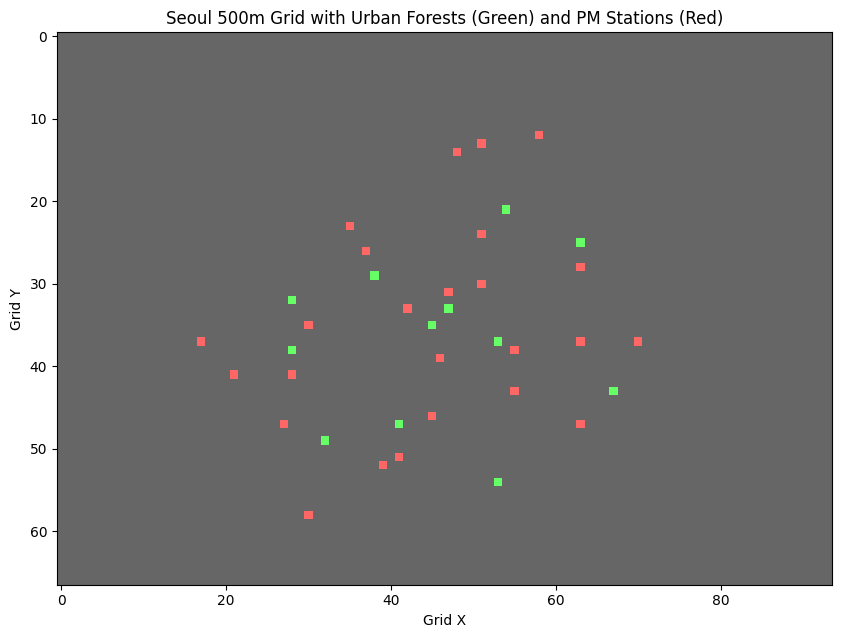

In [ ]:
import matplotlib.pyplot as plt

# 시각화
plt.figure(figsize=(10, 10))
plt.imshow(image, origin='upper', alpha=0.6)
plt.title("Seoul 500m Grid with Urban Forests (Green) and PM Stations (Red)")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")
plt.grid(False)
plt.show()


In [ ]:
fk_hm_park = [
    {'name': 'h1', 'x':20, 'y':35, 'area': 100000},
    {'name': 'h2', 'x':35, 'y':15, 'area': 100000},
    {'name': 'h3', 'x':40, 'y':20, 'area': 100000},
    {'name': 'h4', 'x':45, 'y':25, 'area': 100000},
    {'name': 'h5', 'x':27, 'y':48, 'area': 100000},
    {'name': 'h6', 'x':35, 'y':60, 'area': 100000},
    {'name': 'h7', 'x':30, 'y':45, 'area': 100000}
              ]

# 도시숲 → 초록색
for park in parks:
    r, c = latlon_to_pixel(park["lat"], park["lon"])
    if 0 <= r < n_rows and 0 <= c < n_cols:
        image[r, c, 1] = 1.0  # green

# 측정소 → 빨간색
for station in stations:
    r, c = latlon_to_pixel(station["lat"], station["lon"])
    if 0 <= r < n_rows and 0 <= c < n_cols:
        image[r, c, 0] = 1.0  # red

# 가상도시숲 → 노란색
for fk in fk_hm_park:
    r, c = fk['y'], fk['x']
    if 0 <= r < n_rows and 0 <= c < n_cols:
        image[r, c, 2] = 1.0  # red  # 파란색

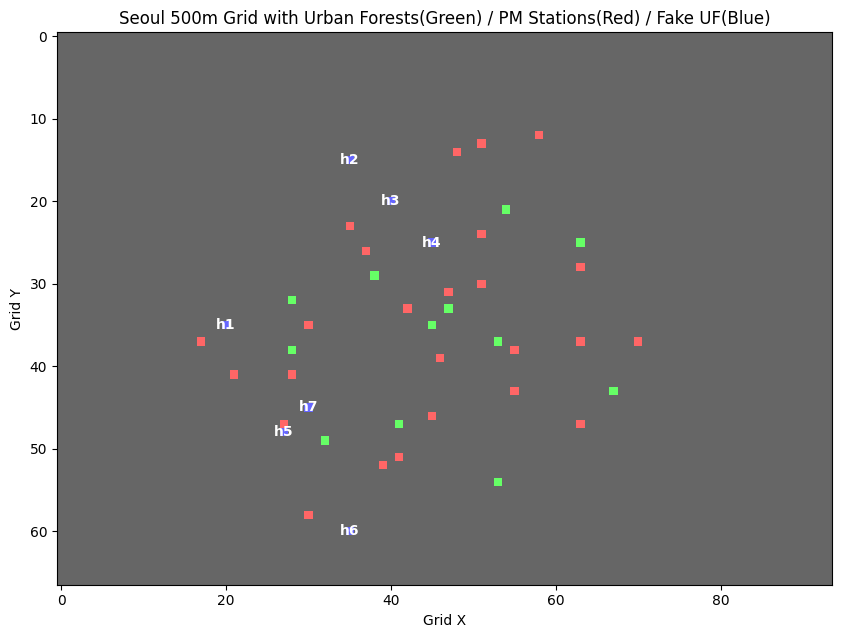

In [ ]:
import matplotlib.pyplot as plt

# 시각화
plt.figure(figsize=(10, 10))
plt.imshow(image, origin='upper', alpha=0.6)
plt.title("Seoul 500m Grid with Urban Forests(Green) / PM Stations(Red) / Fake UF(Blue)")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")

for park in fk_hm_park:
    x = park['x']
    y = park['y']
    name = park['name']
    plt.text(x, y, name, color='white', fontsize=10, ha='center', va='center', weight='bold')

plt.grid(False)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from math import atan2, sin, cos

# 거리 계산 함수
def euclidean_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# 방향 벡터 → sin, cos 변환
def direction_vector(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y1 - y2  # y축 반전
    angle = atan2(-dy, dx)
    return sin(angle), cos(angle)

# DataFrame → dict 리스트
df_parks = pd.DataFrame(parks)
df_stations = pd.DataFrame(stations)

parks = df_parks.to_dict('records')
stations = df_stations.to_dict('records')

# 결과 저장 리스트
records = []

for station in stations:
    sx, sy = station['x'], station['y']

    # 거리 계산
    df_parks['distance'] = df_parks.apply(
        lambda p: euclidean_distance(sx, sy, p['x'], p['y']), axis=1
    )

    # 가까운 3개 공원
    nearest = df_parks.nsmallest(3, 'distance').copy()

    # 원하는 구조로 행 구성
    row = {'station_name': station['name']}

    for i, (_, park) in enumerate(nearest.iterrows(), start=1):
        dir_sin, dir_cos = direction_vector(sx, sy, park['x'], park['y'])
        row[f'park{i}_name'] = park['name']
        row[f'park{i}_dir_sin'] = dir_sin
        row[f'park{i}_dir_cos'] = dir_cos
        row[f'park{i}_distance'] = park['distance']
        row[f'park{i}_area'] = park['area']

    records.append(row)

# 결과 DataFrame
df_final = pd.DataFrame(records)

# 저장
df_final.to_csv("/content/drive/MyDrive/DS teamproj/station_nearest_3parks_vector.csv", index=False)


In [ ]:
df_result = pd.read_csv("/content/drive/MyDrive/DS teamproj/station_nearest_3parks_vector.csv")

# 앞부분 5개 행 출력
df_result.head(5)

,station_name,park1_name,park1_dir_sin,park1_dir_cos,park1_distance,park1_area,park2_name,park2_dir_sin,park2_dir_cos,park2_distance,park2_area,park3_name,park3_dir_sin,park3_dir_cos,park3_distance,park3_area
0,강남구,서울숲,-0.316228,-0.948683,6.324555,1156498,매헌시민의숲,-0.178885,0.983870,11.180340,358992,올림픽공원,1.000000,6.123234e-17,12.000000,1450000
1,강동구,올림픽공원,-0.447214,0.894427,6.708204,1450000,중랑캠핑숲,-0.503871,-0.863779,13.892444,260000,서울숲,-1.000000,6.123234e-17,17.000000,1156498
2,강북구,북서울꿈의숲,0.650791,0.759257,9.219544,662627,안산도시자연공원,-0.554700,0.832050,18.027756,2088704,중랑캠핑숲,0.806405,5.913637e-01,18.601075,260000
3,강서구,선유도공원,0.995893,0.090536,11.045361,110400,월드컵공원,0.910366,-0.413803,12.083046,3471090,보라매공원,0.780869,6.246950e-01,19.209373,425000
4,관악구,현충원,0.371391,-0.928477,5.385165,1440000,보라매공원,-0.919145,-0.393919,7.615773,425000,매헌시민의숲,0.989949,1.414214e-01,14.142136,358992
